Saved to ../data/processed/ercot_load_hourly_2023_2025.csv
Shape: (26301, 2)
Date range: 2023-01-01 01:00:00 -> 2026-01-01 00:00:00
                   dt       load_mw
0 2023-01-01 01:00:00  35609.173887
1 2023-01-01 02:00:00  35012.298856
2 2023-01-01 03:00:00  34369.582295
3 2023-01-01 04:00:00  34000.730337
4 2023-01-01 05:00:00  33865.078669


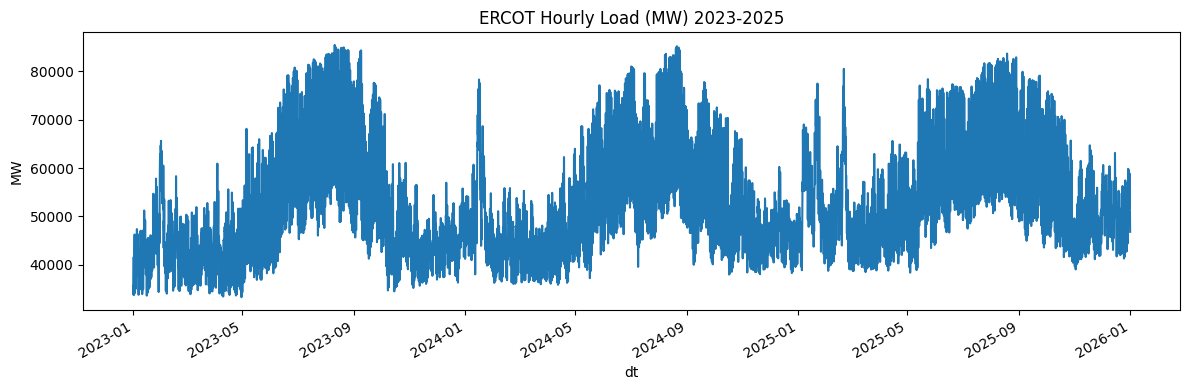

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# -- 1. LOAD FUNCTION
def load_ercot_native_load(path: str) -> pd.DataFrame:
    df = pd.read_excel(path)
    df = df.rename(columns={"Hour Ending": "dt", "ERCOT": "load_mw"})

    s = df["dt"].astype(str)
    date_part = s.str.slice(0, 10)
    time_part = s.str.slice(11)

    date_dt = pd.to_datetime(date_part, format="%m/%d/%Y", errors="raise")
    is_24 = time_part.eq("24:00")
    date_dt = date_dt + pd.to_timedelta(is_24.astype(int), unit="D")
    hour = pd.to_numeric(time_part.str.slice(0, 2), errors="coerce") % 24

    return pd.DataFrame({
        "dt": date_dt + pd.to_timedelta(hour, unit="h"),
        "load_mw": pd.to_numeric(df["load_mw"], errors="coerce"),
    }).sort_values("dt").reset_index(drop=True)

# -- 2. LOAD ALL THREE YEARS
df_2023 = load_ercot_native_load("../data/raw/Native_Load_2023.xlsx")
df_2024 = load_ercot_native_load("../data/raw/Native_Load_2024.xlsx")
df_2025 = load_ercot_native_load("../data/raw/Native_Load_2025.xlsx")

# -- 3. COMBINE AND DEDUPLICATE
df_all = pd.concat([df_2023, df_2024, df_2025], ignore_index=True)
df_all = df_all.drop_duplicates(subset=["dt"]).sort_values("dt").reset_index(drop=True)

# -- 4. SAVE TO PROCESSED
os.makedirs("../data/processed", exist_ok=True)
out_path = "../data/processed/ercot_load_hourly_2023_2025.csv"
df_all.to_csv(out_path, index=False)

print(f"Saved to {out_path}")
print(f"Shape: {df_all.shape}")
print(f"Date range: {df_all['dt'].min()} -> {df_all['dt'].max()}")
print(df_all.head())

# -- 5. PLOT
df_all.set_index("dt")["load_mw"].plot(
    figsize=(12, 4),
    title="ERCOT Hourly Load (MW) 2023-2025"
)
plt.ylabel("MW")
plt.tight_layout()
plt.show()